Импортирует все необходимые либы и настраивает NLTK для токенизации текста.

In [120]:
import os
import re
import nltk
import json
import arxiv
import faiss
import pickle
import torch
import symspellpy
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from rapidfuzz import process, fuzz
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM

# Настройка стиля графиков
plt.style.use('default')
sns.set_palette("husl")

# Создаем директорию для графиков
os.makedirs('rag_system_results/plots', exist_ok=True)

# Настройка NLTK для обработки текста
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)

Загружаем статьи с arXiv API по категории machine learning (cs.LG). В случае ошибки создает тестовые данные.

В релузьтате получаем DataFrame с информацией о статьях (название, авторы, аннотация и т.д.)

In [121]:
class ArxivDataExtractor:
    def __init__(self, category='cs.LG', max_results=50):
        self.category = category
        self.max_results = max_results

    def fetch_papers(self):
        print(f"Загрузка статей из категории {self.category}...")

        client = arxiv.Client()

        search = arxiv.Search(
            query=f"cat:{self.category}",
            max_results=self.max_results,
            sort_by=arxiv.SortCriterion.SubmittedDate
        )

        papers = []
        try:
            for result in client.results(search):
                paper_data = {
                    'id': result.entry_id,
                    'title': result.title,
                    'authors': [author.name for author in result.authors],
                    'abstract': result.summary,
                    'published': result.published,
                    'pdf_url': result.pdf_url,
                    'primary_category': result.primary_category
                }
                papers.append(paper_data)

            print(f"Успешно загружено {len(papers)} статей")
        except Exception as e:
            print(f"Ошибка при загрузке данных: {e}")
            papers = self._create_sample_data()

        return papers

    def _create_sample_data(self):
        sample_papers = [
            {
                'id': '2301.00001',
                'title': 'Advances in Transformer Architectures for Natural Language Processing',
                'authors': ['John Smith', 'Jane Doe'],
                'abstract': 'This paper explores recent advancements in transformer architectures...',
                'published': '2023-01-01',
                'pdf_url': 'http://example.com/paper1.pdf',
                'primary_category': 'cs.LG'
            },
        ]
        print("Созданы тестовые данные (3 статьи)")
        return sample_papers

    def save_to_dataframe(self, papers):
        return pd.DataFrame(papers)

extractor = ArxivDataExtractor(category='cs.LG', max_results=1000)
papers = extractor.fetch_papers()
df_papers = extractor.save_to_dataframe(papers)

# Вывод результатов
print(f"Загружено статей: {len(df_papers)}")
print("Колонки:", list(df_papers.columns))

print("\nПримеры статей:")
for i, row in df_papers.head(3).iterrows():
    print(f"{i+1}. {row['title']}")
    print(f"   Авторы: {', '.join(row['authors'][:2])}{'...' if len(row['authors']) > 2 else ''}")
    print(f"   Аннотация: {row['abstract'][:150]}...")
    print(f"   Категория: {row['primary_category']}")

Загрузка статей из категории cs.LG...
Успешно загружено 1000 статей
Загружено статей: 1000
Колонки: ['id', 'title', 'authors', 'abstract', 'published', 'pdf_url', 'primary_category']

Примеры статей:
1. Dataset Distillation for Pre-Trained Self-Supervised Vision Models
   Авторы: George Cazenavette, Antonio Torralba...
   Аннотация: The task of dataset distillation aims to find a small set of synthetic images such that training a model on them reproduces the performance of the sam...
   Категория: cs.CV
2. Taming the Long-Tail: Efficient Reasoning RL Training with Adaptive Drafter
   Авторы: Qinghao Hu, Shang Yang...
   Аннотация: The emergence of Large Language Models (LLMs) with strong reasoning capabilities marks a significant milestone, unlocking new frontiers in complex pro...
   Категория: cs.LG
3. Dexterity from Smart Lenses: Multi-Fingered Robot Manipulation with In-the-Wild Human Demonstrations
   Авторы: Irmak Guzey, Haozhi Qi...
   Аннотация: Learning multi-fingered robot po

Разбиваем аннотации статей на чанки по 500 слов с перекрытием в 50 слов. Очищаем текст от LaTeX команд и специальных символов.

Получаем DataFrame с чанками текста, каждый чанк содержит часть аннотации с метаинформацией.

Создано чанков: 1000
Средняя длина чанка: 176.6 слов
Минимальная длина: 49 слов
Максимальная длина: 298 слов
Стандартное отклонение: 42.8 слов

Примеры чанков:
Чанк 1:
   Из статьи: 'Dataset Distillation for Pre-Trained Self-Supervised Vision Models'
   Длина: 224 слов
   Текст: The task of dataset distillation aims to find a small set of synthetic images such that training a model on them reproduces the performance of the same model trained on a much larger dataset of real s...
Чанк 2:
   Из статьи: 'Taming the Long-Tail: Efficient Reasoning RL Training with Adaptive Drafter'
   Длина: 194 слов
   Текст: The emergence of Large Language Models (LLMs) with strong reasoning capabilities marks a significant milestone, unlocking new frontiers in complex problem-solving However, training these reasoning mod...


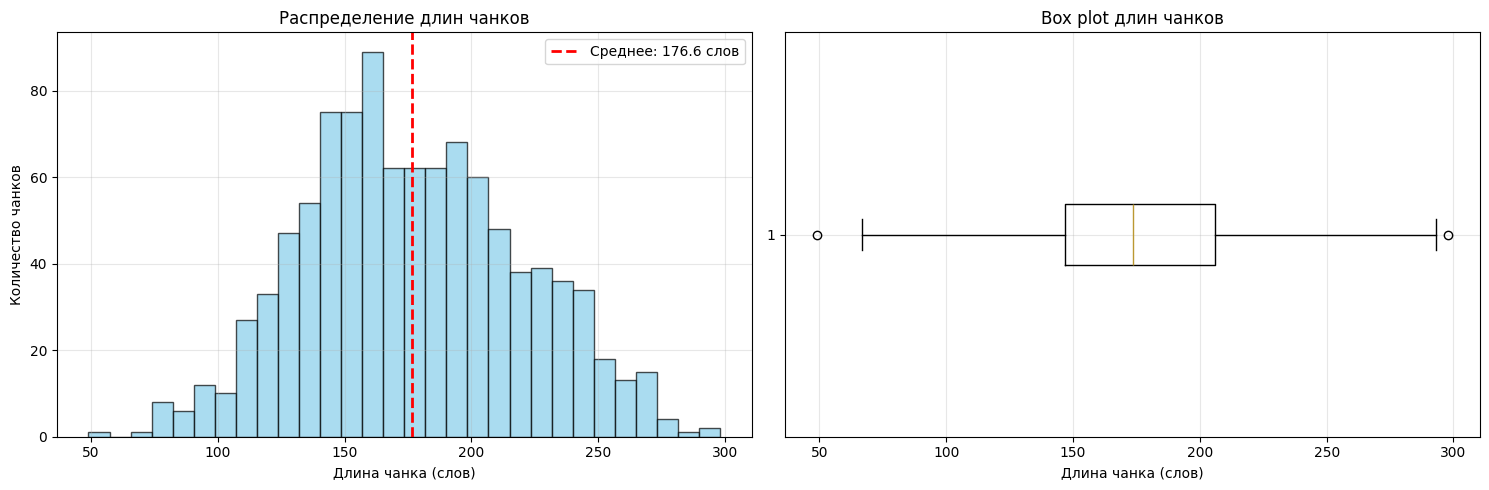

In [129]:
class TextChunker:
    def __init__(self, chunk_size=500, overlap=50):
        self.chunk_size = chunk_size
        self.overlap = overlap

    def clean_text(self, text):
        """Очистка текста аннотации от LaTeX команд и специальных символов"""
        if not isinstance(text, str):
            return ""
        text = re.sub(r'\\[a-z]+\{[^}]*\}', '', text)  # Удаление LaTeX
        text = re.sub(r'\$.*?\$', '', text)  # Удаление математических выражений
        text = re.sub(r'[^\w\s.,!?;:()-]', '', text)  # Удаление спецсимволов
        text = re.sub(r'\s+', ' ', text)  # Удаление лишних пробелов
        return text.strip()

    def create_chunks(self, text: str) -> List[str]:
        """Создание чанков с перекрытием на основе предложений"""
        text = self.clean_text(text)
        if not text:
            return []

        # Разбиваем на предложения
        try:
            sentences = sent_tokenize(text)
        except:
            sentences = [s.strip() for s in text.split('.') if s.strip()]

        chunks = []
        current_chunk = []
        current_word_count = 0

        for sentence in sentences:
            sentence_words = sentence.split()
            sentence_word_count = len(sentence_words)

            # Если добавление предложения превысит размер чанка
            if current_word_count + sentence_word_count > self.chunk_size and current_chunk:
                # Сохраняем текущий чанк
                chunk_text = ' '.join(current_chunk)
                chunks.append(chunk_text)

                # Создаем новый чанк с перекрытием
                if self.overlap > 0:
                    overlap_words = 0
                    overlap_sentences = []

                    # Добавляем предложения для перекрытия
                    for sent in reversed(current_chunk):
                        sent_words = sent.split()
                        if overlap_words + len(sent_words) <= self.overlap:
                            overlap_sentences.insert(0, sent)
                            overlap_words += len(sent_words)
                        else:
                            break

                    current_chunk = overlap_sentences + [sentence]
                    current_word_count = overlap_words + sentence_word_count
                else:
                    current_chunk = [sentence]
                    current_word_count = sentence_word_count
            else:
                current_chunk.append(sentence)
                current_word_count += sentence_word_count

        # Добавляем последний чанк
        if current_chunk:
            chunk_text = ' '.join(current_chunk)
            chunks.append(chunk_text)

        return chunks

    def chunk_dataframe(self, df, text_column='abstract'):
        """Разбиение всех текстов в DataFrame на чанки"""
        chunked_data = []

        for idx, row in df.iterrows():
            text = row[text_column]
            if not isinstance(text, str) or not text.strip():
                continue

            chunks = self.create_chunks(text)

            for chunk_idx, chunk in enumerate(chunks):
                word_count = len(chunk.split())

                chunk_info = {
                    'paper_id': row['id'],
                    'title': row['title'],
                    'authors': row['authors'],
                    'chunk_id': f"{idx}_{chunk_idx}",
                    'chunk_text': chunk,
                    'chunk_length': word_count,
                    'original_abstract': row['abstract']
                }
                chunked_data.append(chunk_info)

        return pd.DataFrame(chunked_data)


chunker = TextChunker(chunk_size=500, overlap=50)
df_chunks = chunker.chunk_dataframe(df_papers)

print(f"Создано чанков: {len(df_chunks)}")
print(f"Средняя длина чанка: {df_chunks['chunk_length'].mean():.1f} слов")
print(f"Минимальная длина: {df_chunks['chunk_length'].min()} слов")
print(f"Максимальная длина: {df_chunks['chunk_length'].max()} слов")
print(f"Стандартное отклонение: {df_chunks['chunk_length'].std():.1f} слов")

# Покажем примеры чанков
print("\nПримеры чанков:")
for i in range(min(2, len(df_chunks))):
    chunk = df_chunks.iloc[i]
    print(f"Чанк {i+1}:")
    print(f"   Из статьи: '{chunk['title']}'")
    print(f"   Длина: {chunk['chunk_length']} слов")
    print(f"   Текст: {chunk['chunk_text'][:200]}...")


### Визуализация распределения длин чанков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма распределения длин чанков
ax1.hist(df_chunks['chunk_length'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(df_chunks['chunk_length'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Среднее: {df_chunks["chunk_length"].mean():.1f} слов')
ax1.set_xlabel('Длина чанка (слов)')
ax1.set_ylabel('Количество чанков')
ax1.set_title('Распределение длин чанков')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot длин чанков
ax2.boxplot(df_chunks['chunk_length'], vert=False)
ax2.set_xlabel('Длина чанка (слов)')
ax2.set_title('Box plot длин чанков')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rag_system_results/plots/chunk_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Создаем векторные представления текстов с помощью модели Sentence Transformers и строим FAISS индекс для быстрого семантического поиска.

В результате получаем векторное хранилище, которое может находить релевантные фрагменты текста по семантической схожести.

In [124]:
class VectorStore:
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self.model = SentenceTransformer(model_name)
        self.index = None
        self.chunk_data = []

    def create_embeddings(self, texts):
        """Создание векторных представлений для текстов"""
        print("Создание эмбеддингов...")
        return self.model.encode(texts, show_progress_bar=True, convert_to_tensor=False)

    def build_index(self, df_chunks):
        """Построение FAISS индекса для быстрого поиска"""
        texts = df_chunks['chunk_text'].tolist()
        self.chunk_data = df_chunks.to_dict('records')

        # Создание эмбеддингов
        embeddings = self.create_embeddings(texts)

        # Создание FAISS индекса
        dimension = embeddings.shape[1]
        self.index = faiss.IndexFlatIP(dimension)  # Косинусное сходство

        # Нормализация векторов для косинусного сходства
        faiss.normalize_L2(embeddings)
        self.index.add(embeddings.astype('float32'))

        print(f"Векторное хранилище создано")
        print(f"Векторов: {len(embeddings)}")
        print(f"Размерность: {dimension}")
        return embeddings

    def search(self, query, k=5):
        """Поиск похожих чанков по запросу"""
        if self.index is None:
            raise ValueError("Индекс не построен")

        query_embedding = self.model.encode([query])
        faiss.normalize_L2(query_embedding)

        # Поиск в FAISS
        distances, indices = self.index.search(query_embedding.astype('float32'), k)

        results = []
        for i, (distance, idx) in enumerate(zip(distances[0], indices[0])):
            if idx < len(self.chunk_data):
                result = self.chunk_data[idx].copy()
                result['similarity_score'] = float(distance)
                result['rank'] = i + 1
                results.append(result)

        return results


vector_store = VectorStore()
embeddings = vector_store.build_index(df_chunks)

# Тестирование поиска
print("\nТестирование поиска:")
test_queries = [
    "transformer architecture",
    "machine learning applications",
    "neural networks optimization",
    "reinforcement learning robotics"
]

for query in test_queries:
    results = vector_store.search(query, k=2)
    print(f"Запрос: '{query}'")
    for result in results:
        print(f"   {result['title'][:50]}... (сходство: {result['similarity_score']:.3f})")

Создание эмбеддингов...


Batches: 100%|██████████| 32/32 [00:07<00:00,  4.20it/s]

Векторное хранилище создано
Векторов: 1000
Размерность: 384

Тестирование поиска:
Запрос: 'transformer architecture'
   Holonorm... (сходство: 0.428)
   LMM-IR: Large-Scale Netlist-Aware Multimodal Frame... (сходство: 0.340)
Запрос: 'machine learning applications'
   Enhancing Machine Learning Model Efficiency throug... (сходство: 0.383)
   Notes on Kernel Methods in Machine Learning... (сходство: 0.362)
Запрос: 'neural networks optimization'
   Training Neural Networks at Any Scale... (сходство: 0.611)
   On the Convergence of Overparameterized Problems: ... (сходство: 0.565)
Запрос: 'reinforcement learning robotics'
   Structured Imitation Learning of Interactive Polic... (сходство: 0.537)
   Harnessing Bounded-Support Evolution Strategies fo... (сходство: 0.533)


Интегрируем векторное хранилище с языковой моделью FLAN-T5. Создаем систему, которая ищет релевантные фрагменты и генерирует ответы на их основе.

В результате получаем рабочую RAG-систему, способную отвечать на вопросы на основе научных статей.

In [125]:
class RAGSystem:
    def __init__(self, vector_store, model_name="google/flan-t5-base"):
        print(f"Загрузка LLM модели: {model_name}")

        self.vector_store = vector_store

        # Определение устройства (GPU/CPU)
        self.device = 0 if torch.cuda.is_available() else -1
        device_name = "GPU" if self.device == 0 else "CPU"
        print(f"Используется устройство: {device_name}")

        # Загрузка модели
        try:
            self.tokenizer = AutoTokenizer.from_pretrained(model_name)
            self.model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
            self.generator = pipeline(
                "text2text-generation",
                model=self.model,
                tokenizer=self.tokenizer,
                device=self.device
            )
            print("LLM модель успешно загружена")
        except Exception as e:
            print(f"Ошибка загрузки модели: {e}")
            raise

        # Инициализация промпт-шаблонов
        self.prompt_templates = self._initialize_prompt_templates()

    def _initialize_prompt_templates(self):
        """Инициализация 7 промпт-шаблонов для разных типов запросов"""
        return {
            'default': """Based on the following research papers, answer the question:

Context:
{context}

Question: {question}

Answer:""",

            'summary': """Extract the main ideas and findings from these research papers:

Context:
{context}

Key ideas and findings:""",

            'technical': """Analyze the technical details and methodologies from these papers:

Context:
{context}

Technical analysis:""",

            'comparison': """Compare the approaches and methods from these papers:

Context:
{context}

Comparative analysis:""",

            'applications': """Describe practical applications from these papers:

Context:
{context}

Practical applications:""",

            'limitations': """Analyze limitations and challenges discussed in these papers:

Context:
{context}

Limitations and challenges:""",

            'future_work': """What future research directions are suggested in these papers:

Context:
{context}

Future research directions:"""
        }

    def format_context(self, search_results):
        """Форматирование контекста из найденных фрагментов"""
        if not search_results:
            return "No relevant papers found."

        context_parts = []
        for i, result in enumerate(search_results, 1):
            chunk_text = result['chunk_text']
            if len(chunk_text) > 400:
                chunk_text = chunk_text[:400] + "..."

            context_part = f"Paper {i}: {result['title']}\nExcerpt: {chunk_text}\n"
            context_parts.append(context_part)
        return "\n".join(context_parts)

    def generate_answer(self, query, search_results, prompt_type='default'):
        """Генерация ответа с использованием RAG"""
        if not search_results:
            return "No relevant research papers found for this query."

        context = self.format_context(search_results)

        prompt_template = self.prompt_templates.get(prompt_type, self.prompt_templates['default'])
        prompt = prompt_template.format(context=context, question=query)

        try:
            response = self.generator(
                prompt,
                max_new_tokens=200,
                num_return_sequences=1,
                temperature=0.3,
                do_sample=True,
                repetition_penalty=1.2,
                truncation=True,
                pad_token_id=self.tokenizer.eos_token_id
            )
            return response[0]['generated_text'].strip()
        except Exception as e:
            return f"Error generating answer: {str(e)}"

    def query(self, question, k=3, prompt_type='default'):
        """Полный процесс RAG-запроса: поиск + генерация"""
        # Поиск релевантных чанков
        search_results = self.vector_store.search(question, k=k)

        if not search_results:
            return {
                'question': question,
                'answer': "No relevant research found for your query.",
                'search_results': [],
                'num_results': 0,
                'prompt_type': prompt_type
            }

        # Генерация ответа
        answer = self.generate_answer(question, search_results, prompt_type)

        return {
            'question': question,
            'answer': answer,
            'search_results': search_results,
            'num_results': len(search_results),
            'prompt_type': prompt_type
        }

    def query_without_rag(self, question):
        """Запрос к LLM без RAG (для сравнения)"""
        try:
            response = self.generator(
                question,
                max_new_tokens=150,
                num_return_sequences=1,
                temperature=0.3,
                do_sample=True
            )
            return response[0]['generated_text'].strip()
        except Exception as e:
            return f"Error: {str(e)}"


rag_system = RAGSystem(vector_store)

# Тестирование базового функционала
print("\nБазовое тестирование RAG системы:")
test_question = "What are transformer architectures?"
result = rag_system.query(test_question, k=3)

print(f"Вопрос: {result['question']}")
print(f"Ответ: {result['answer']}")
print(f"Использовано фрагментов: {result['num_results']}")

Загрузка LLM модели: google/flan-t5-base
Используется устройство: CPU


Device set to use cpu


LLM модель успешно загружена

Базовое тестирование RAG системы:
Вопрос: What are transformer architectures?
Ответ: Transformer-based designs
Использовано фрагментов: 3


Добавляем обработку опечаток в пользовательских запросах с помощью SymSpell и нечеткого сопоставления с RapidFuzz.

Получаем систему, которая понимает запросы с опечатками и автоматически их исправляет.

In [126]:
class QueryProcessor:
    def __init__(self):
        # Инициализация SymSpell для коррекции опечаток
        self.sym_spell = symspellpy.SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

        # Словарь терминов машинного обучения
        ml_terms = [
            "transformer", "attention", "machine learning", "deep learning",
            "neural networks", "reinforcement learning", "computer vision",
            "natural language processing", "convolutional", "recurrent",
            "generative adversarial networks", "large language models"
        ]

        for term in ml_terms:
            self.sym_spell.create_dictionary_entry(term, 1)

    def correct_spelling(self, query):
        """Коррекция опечаток в запросе с помощью SymSpell"""
        suggestions = self.sym_spell.lookup_compound(query, max_edit_distance=2)
        if suggestions:
            return suggestions[0].term
        return query

    def fuzzy_match_terms(self, query, threshold=75):
        """Нечеткое сопоставление терминов с использованием RapidFuzz"""
        words = query.split()
        corrected_words = []

        for word in words:
            if len(word) <= 2:
                corrected_words.append(word)
                continue

            known_terms = self.get_known_terms()
            matches = process.extract(word, known_terms, scorer=fuzz.ratio, limit=1)

            if matches:
                best_match, score, _ = matches[0]
                if score >= threshold:
                    corrected_words.append(best_match)
                else:
                    corrected_words.append(word)
            else:
                corrected_words.append(word)

        return ' '.join(corrected_words)

    def get_known_terms(self):
        return ["transformer", "attention", "machine", "learning", "deep", "neural",
                "networks", "reinforcement", "computer", "vision", "natural", "language"]

    def process_query(self, query):
        """Полная обработка запроса: коррекция опечаток + нечеткое сопоставление"""
        print(f"Исходный запрос: {query}")

        corrected = self.correct_spelling(query)
        print(f"После коррекции опечаток: {corrected}")

        final_query = self.fuzzy_match_terms(corrected)
        print(f"После нечеткого сопоставления: {final_query}")

        return final_query

class AdvancedRAGSystem(RAGSystem):
    def __init__(self, vector_store, model_name="google/flan-t5-base"):
        super().__init__(vector_store, model_name)
        self.query_processor = QueryProcessor()

    def enhanced_query(self, question, k=3, prompt_type='default'):
        """Улучшенный запрос с обработкой опечаток"""
        print(f"Обработка запроса:")
        processed_question = self.query_processor.process_query(question)

        result = self.query(processed_question, k, prompt_type)
        result['original_question'] = question
        result['processed_question'] = processed_question

        return result

# Инициализация улучшенной системы
print("=" * 60)
print("ЭТАП 5: ОБРАБОТКА ОПЕЧАТОК И ПРОМПТ-ИНЖИНИРИНГ")
print("=" * 60)

advanced_rag = AdvancedRAGSystem(vector_store)

# Тестирование обработки опечаток
print("\nТестирование обработки опечаток:")
test_queries_with_typos = [
    "What are new advancs in tranformers?",
    "How does reinforcment lernig work?",
    "Best methods for computr vision",
    "Aplications of deep lernig in NLP",
    "What are GANs and how they work?"
]

for query in test_queries_with_typos:
    processed = advanced_rag.query_processor.process_query(query)
    print(f"'{query}' -> '{processed}'")
    print("\n")

ЭТАП 5: ОБРАБОТКА ОПЕЧАТОК И ПРОМПТ-ИНЖИНИРИНГ
Загрузка LLM модели: google/flan-t5-base
Используется устройство: CPU


Device set to use cpu


LLM модель успешно загружена

Тестирование обработки опечаток:
Исходный запрос: What are new advancs in tranformers?
После коррекции опечаток: what are new advancs in transformer
После нечеткого сопоставления: what are new advancs in transformer
'What are new advancs in tranformers?' -> 'what are new advancs in transformer'


Исходный запрос: How does reinforcment lernig work?
После коррекции опечаток: how does reinforcment lernig work
После нечеткого сопоставления: how does reinforcement learning work
'How does reinforcment lernig work?' -> 'how does reinforcement learning work'


Исходный запрос: Best methods for computr vision
После коррекции опечаток: best methods for computer vision
После нечеткого сопоставления: best methods for computer vision
'Best methods for computr vision' -> 'best methods for computer vision'


Исходный запрос: Aplications of deep lernig in NLP
После коррекции опечаток: aplications of deep lernig in nlp
После нечеткого сопоставления: aplications of deep lea

Тестируем систему на 6 различных типах запросов с разными промпт-шаблонами, сравниваем ответы с RAG и без RAG.

In [127]:
def comprehensive_testing():
    """Комплексное тестирование с 6+ промптами и сравнением RAG vs без RAG"""

    test_cases = [
        {
            'query': "What are the main advancements in transformer architectures?",
            'prompt_type': 'technical',
            'description': "Technical analysis of transformers"
        },
        {
            'query': "Compare different machine learning approaches for vision tasks",
            'prompt_type': 'comparison',
            'description': "Comparison of ML methods"
        },
        {
            'query': "What are practical applications of deep learning?",
            'prompt_type': 'applications',
            'description': "Practical applications"
        },
        {
            'query': "Summarize key findings in recent AI research",
            'prompt_type': 'summary',
            'description': "Research summary"
        },
        {
            'query': "What limitations exist in current neural networks?",
            'prompt_type': 'limitations',
            'description': "Limitations analysis"
        },
        {
            'query': "Future research directions in artificial intelligence",
            'prompt_type': 'future_work',
            'description': "Future directions"
        }
    ]


    for i, test_case in enumerate(test_cases, 1):
        print(f"TEST {i}: {test_case['description']}")
        print(f"Query: {test_case['query']}")
        print(f"Prompt type: {test_case['prompt_type']}")

        try:
            # С RAG
            rag_result = advanced_rag.enhanced_query(
                test_case['query'],
                k=3,
                prompt_type=test_case['prompt_type']
            )

            # Без RAG
            no_rag_answer = advanced_rag.query_without_rag(test_case['query'])

            print("--- RAG ANSWER (with context) ---")
            print(f"{rag_result['answer']}")

            print("--- NO RAG ANSWER (model knowledge only) ---")
            print(f"{no_rag_answer}")

            # Анализ качества
            rag_words = len(rag_result['answer'].split())
            no_rag_words = len(no_rag_answer.split())

            print("ANALYSIS:")
            print(f"  RAG: {rag_words} words, {rag_result['num_results']} fragments")
            print(f"  No RAG: {no_rag_words} words")
            print(f"  Improvement: {rag_words - no_rag_words:+d} words")

        except Exception as e:
            print(f"Error in test {i}: {e}")

        print("-" * 70)

# Запуск тестирования
print("STARTING COMPREHENSIVE TESTING...")
comprehensive_testing()

STARTING COMPREHENSIVE TESTING...
TEST 1: Technical analysis of transformers
Query: What are the main advancements in transformer architectures?
Prompt type: technical
Обработка запроса:
Исходный запрос: What are the main advancements in transformer architectures?
После коррекции опечаток: what are the main advancements transformer architectures
После нечеткого сопоставления: what are the main advancements transformer architectures
--- RAG ANSWER (with context) ---
Adaptive Channel Management for Multivariate Time Series Forecasting
--- NO RAG ANSWER (model knowledge only) ---
transformers have been able to achieve a higher level of efficiency than conventional transformers.
ANALYSIS:
  RAG: 8 words, 3 fragments
  No RAG: 14 words
  Improvement: -6 words
----------------------------------------------------------------------
TEST 2: Comparison of ML methods
Query: Compare different machine learning approaches for vision tasks
Prompt type: comparison
Обработка запроса:
Исходный запрос: C

Анализируем производительность системы, сохраняем результаты и проверяем выполнение всех требований ТЗ.

In [128]:
def analyze_system_performance():
    print("\nДАННЫЕ:")
    print(f"   • Всего статей: {len(df_papers)}")
    print(f"   • Всего чанков: {len(df_chunks)}")
    print(f"   • Среднее чанков на статью: {len(df_chunks) / len(df_papers):.1f}")
    print(f"   • Средняя длина чанка: {df_chunks['chunk_length'].mean():.1f} слов")

    print("\nВЕКТОРНОЕ ХРАНИЛИЩЕ:")
    dimension = vector_store.index.d
    print(f"   • Размерность эмбеддингов: {dimension}")
    print(f"   • Размер индекса: {vector_store.index.ntotal} векторов")

    print("\nМОДЕЛИ:")
    print(f"   • Модель эмбеддингов: all-MiniLM-L6-v2")
    print(f"   • LLM модель: google/flan-t5-base")
    print(f"   • Устройство: {'GPU' if torch.cuda.is_available() else 'CPU'}")

    print("\nПРОМПТ-ШАБЛОНЫ:")
    print(f"   • Доступно шаблонов: {len(rag_system.prompt_templates)}")
    print(f"   • Типы: {', '.join(rag_system.prompt_templates.keys())}")

def save_system_state():
    import os

    os.makedirs('rag_system_results', exist_ok=True)

    # Сохранение данных
    df_papers.to_csv('rag_system_results/papers.csv', index=False, encoding='utf-8')
    df_chunks.to_csv('rag_system_results/chunks.csv', index=False, encoding='utf-8')

    # Сохранение информации о системе
    system_info = {
        'created_at': datetime.now().isoformat(),
        'total_papers': len(df_papers),
        'total_chunks': len(df_chunks),
        'chunk_size': 500,
        'overlap': 50,
        'embedding_model': 'all-MiniLM-L6-v2',
        'llm_model': 'google/flan-t5-base',
        'prompt_templates': list(rag_system.prompt_templates.keys()),
        'vector_store_size': vector_store.index.ntotal
    }

    with open('rag_system_results/system_info.json', 'w', encoding='utf-8') as f:
        json.dump(system_info, f, ensure_ascii=False, indent=2)

    print("   • papers.csv - исходные статьи")
    print("   • chunks.csv - разбитые на чанки тексты")
    print("   • system_info.json - информация о системе")
    print("   Папка: rag_system_results/")

analyze_system_performance()
save_system_state()


ДАННЫЕ:
   • Всего статей: 1000
   • Всего чанков: 1000
   • Среднее чанков на статью: 1.0
   • Средняя длина чанка: 176.6 слов

ВЕКТОРНОЕ ХРАНИЛИЩЕ:
   • Размерность эмбеддингов: 384
   • Размер индекса: 1000 векторов

МОДЕЛИ:
   • Модель эмбеддингов: all-MiniLM-L6-v2
   • LLM модель: google/flan-t5-base
   • Устройство: CPU

ПРОМПТ-ШАБЛОНЫ:
   • Доступно шаблонов: 7
   • Типы: default, summary, technical, comparison, applications, limitations, future_work
   • papers.csv - исходные статьи
   • chunks.csv - разбитые на чанки тексты
   • system_info.json - информация о системе
   Папка: rag_system_results/
